# TUTORIAL: Class ESN_model




* [How to setup a `ESN_model`?](#first)
    * [Data generation](#first_a)
    * [Initialization with training](#first_b)
    * [Saving/Loading ESN_model](#second)
* [Ensemble of ESN_models](#fourth)




# 1. How to setup a `ESN_model` <a class="anchor" id="first"></a>


The class `ESN_model` defined in `src.models_data_driven` and it combines the classes 
* `EchoStateNetwork`, from `tools.esn_core`, and 
* `Model` `from model`. 


In [1]:
from romda.models.data_driven import ESN_model



## 1.1. Data generation <a class="anchor" id="first_a"></a>

To create a any model from `models_datadriven` we need some data to learn. Let's use the Lorenz 63 again.

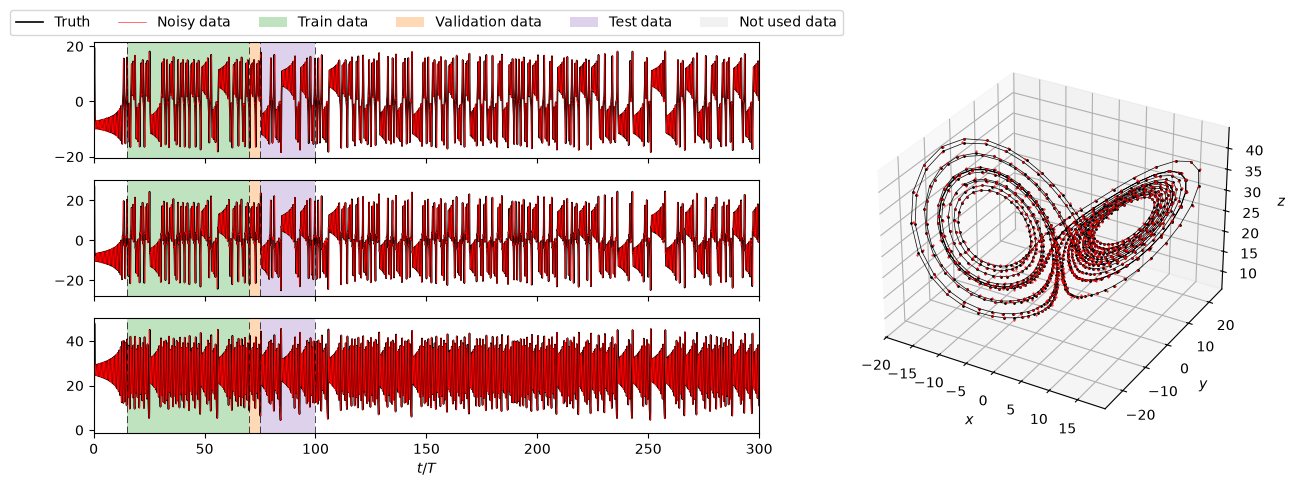

In [2]:
from romda.plotting import plot_train_dataset
from romda.utils import create_Lorenz63_dataset

dataset, filename = create_Lorenz63_dataset(noise_level=0.02, num_lyap_times=300)


clean_data, noisy_data, t, N_lyap = [dataset[key] for key in ['clean_data', 'noisy_data', 
                                                              't', 'N_lyap']]

dt = t[1] - t[0]
t_lyap = N_lyap * dt


# Split the dataset 
N_transient = 15 * N_lyap
N_val = 5 * N_lyap
N_train = 60 * N_lyap - N_val 
N_test = 5 * N_val

# Visualize
split_times = [tt / N_lyap for tt in [N_transient, N_train, N_val, N_test]]
plot_train_dataset(clean_data, noisy_data, t/t_lyap, *split_times)


## 1.2. Initialization with training <a class="anchor" id="first_b"></a>

Training ESN model...


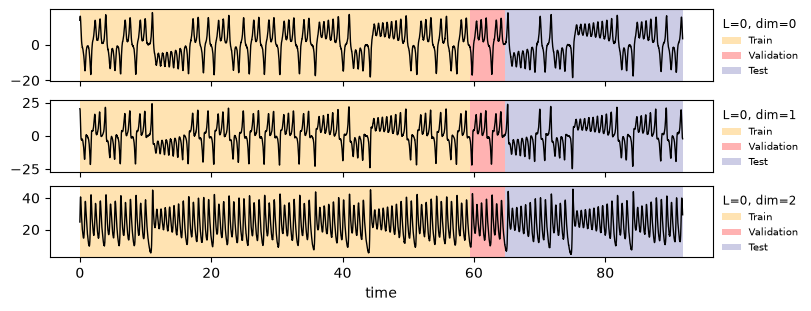


 ----------------- HYPERPARAMETER SEARCH ------------------
 4^2 grid and 4 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 MSE val 


1	 2.000e-01	 1.000e-02	 1.000e-06	 -1.0110


2	 2.000e-01	 2.154e-01	 1.000e-12	 -0.9565


3	 2.000e-01	 4.642e+00	 1.000e-09	 -1.0605
4	 2.000e-01	 1.000e+02	 1.000e-12	 -0.6716


5	 4.000e-01	 1.000e-02	 1.000e-09	 -1.0099


...

18	 2.945e-01	 1.818e+00	 1.000e-09	 -1.4046


19	 3.925e-01	 1.144e+00	 1.000e-06	 -1.0246


20	 2.774e-01	 1.768e+00	 1.000e-09	 -1.3046


seed 0 	 Optimal hyperparameters: [0.29450145262857075, 0.2595073828500545], 1e-09, MSE: -1.4045767224890637
Running test for L= 0 

Overall tests min, max and mean MSE in 1 tests = -0.9347, -0.9347, -0.9347.


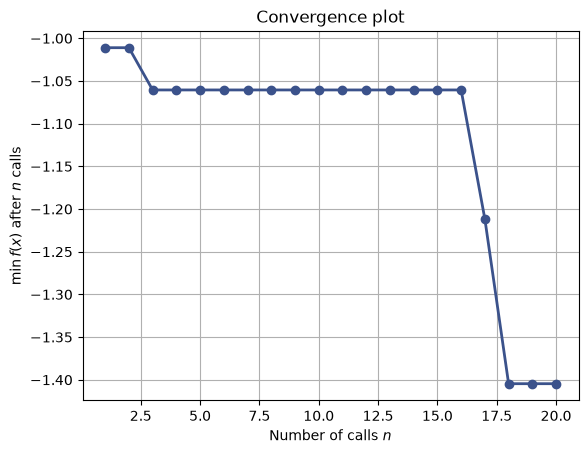

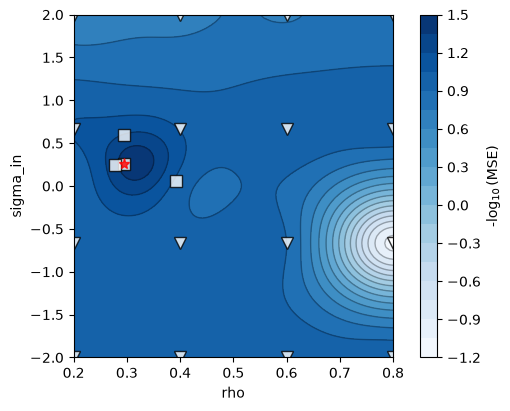

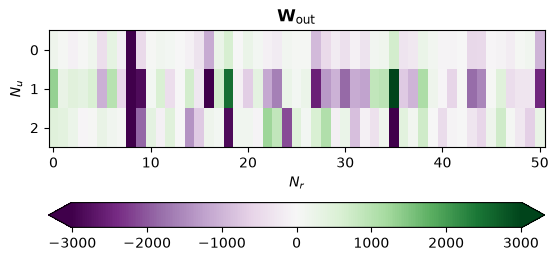

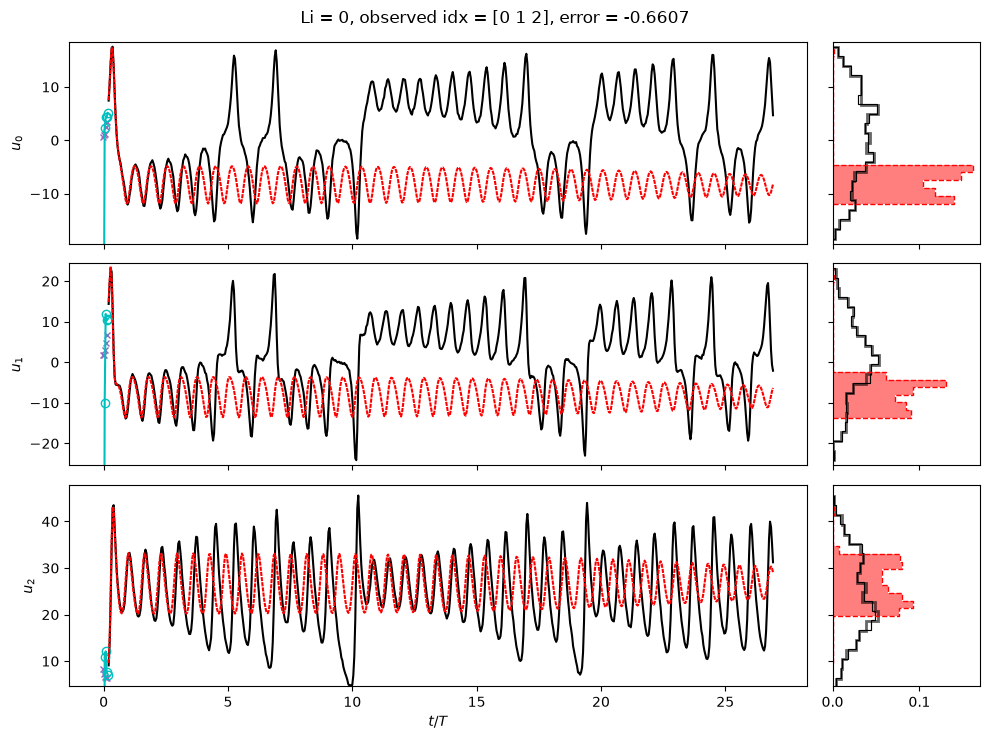

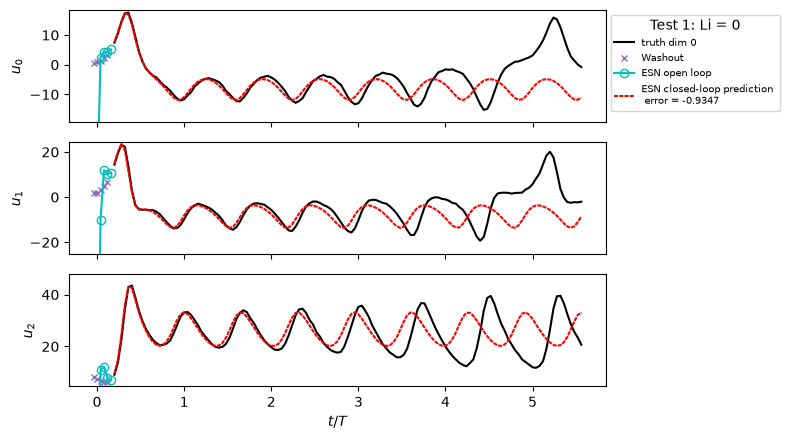

In [3]:
training_data = noisy_data[N_transient:sum([N_transient, N_train, N_val, N_test])]

train_params = dict(N_train=N_train,
                    N_val=N_val,
                    N_test=N_test,
                    dt=dt,
                    upsample=2,
                    N_folds=5,
                    N_grid=4,
                    N_func_evals=20,
                    training_data_filename=filename # Not used in ESN_model itself, but for saving/loading
                    )

# Initialize the ESN model with the training data and parameters. 
# This will also perform hyperparameter optimization and training. 

model = ESN_model(data=training_data, plot_training=True, **train_params)
model_og = model.copy() # Save the original model for comparison later



Once initialized, the model behaves as a `Model` instance (see tutorial [00_Class_Model](00_Class_Model.ipynb)). For example, we can forecast the ESN as

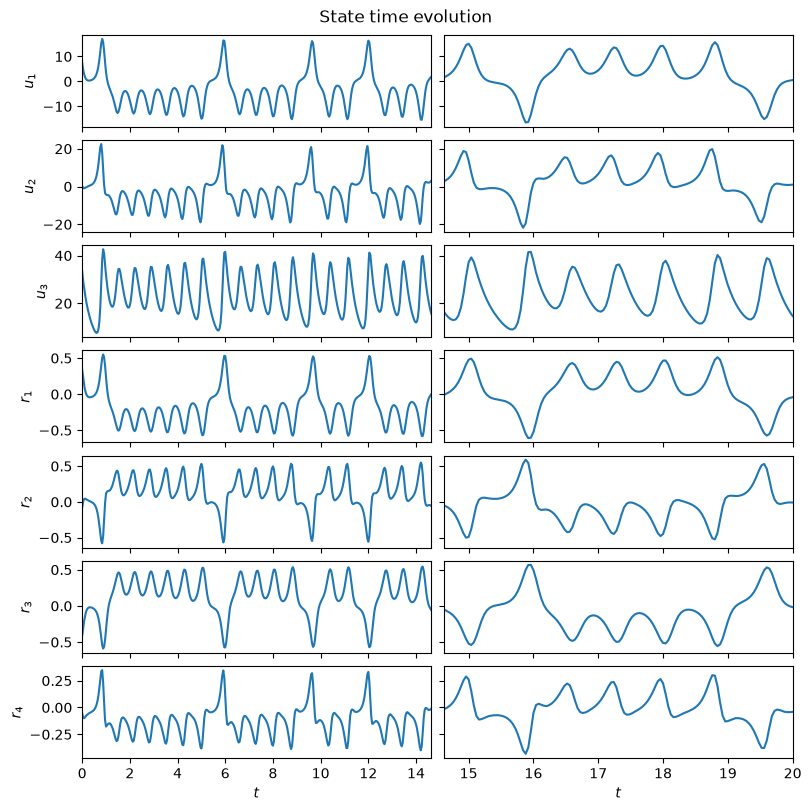

In [4]:

psi, t = model.time_integrate(1000)
model.update_history(psi, t)

# Visualize the state and reservoir state histories
model.visualize_state_hist(max_modes=7)


## 1.3. Saving and Loading ESN models <a class="anchor" id="second"></a>


The `ESNConfig` dataclass from `config.esn_config` is designed to streamline the loading and saving of ESN models without the need to train them. 

The naming of the configs is the _hash_, which is based on the settings of the ESN_model, and can be used to identify the model configuration. Note that the hash is independent on wether the model is trained or not: 

In [5]:
from romda.models.data_driven.esn_config import ESNConfig

# Create an ESNConfig from the trained model and get its hash
config = ESNConfig.from_esn_model(model)
hash_from_model = config.to_hash()

# From the same initialization parameters, we should get the same hash even if we did not go through the training process. 
config_2 = ESNConfig.from_init_params(data=training_data, **train_params)
hash_from_init_params = config_2.to_hash()

assert hash_from_model == hash_from_init_params, "Hashes do not match! There may be an issue with the hashing or the parameters used for initialization."

print('Model hash == Init params hash:', hash_from_init_params)

Model hash == Init params hash: fa2067c4e7b6931a


(A) Saving the config from the model. This creates a folder under `esn_configs` with the hash name.

In [6]:
from romda.models.data_driven.esn_config import save_esn_model_to_config

saved_config, save_path = save_esn_model_to_config(model) # Note: this will overrite any existing config with the same name

Configuration saved to ...config/esn_configs/fa2067c4e7b6931a/esn_config.yaml
Trained matrices saved to ...config/esn_configs/fa2067c4e7b6931a/trained_matrices.npz


(B) Loading model from config. Ether by providing the config instance to the path to the hash folder

In [7]:
from romda.models.data_driven.esn_config import load_esn_model_from_config, ESN_STORE
import numpy as np
from romda.estimators import EnSRKF

loaded_model = load_esn_model_from_config(q=hash_from_model) # load from the hash directly
# loaded_model = load_esn_model_from_config(config=config_2) # load using the query string to find the config

assert loaded_model is not None
#  check that the loaded model produces the same output as the original model
psi_og, t_og = model_og.time_integrate(100)
psi_loaded, t_loaded = loaded_model.time_integrate(100)

assert np.allclose(psi_og, psi_loaded), "Loaded model 1 does not produce the same output as the original model"


✓ Found matching config: fa2067c4e7b6931a
Configuration loaded from ...config/esn_configs/fa2067c4e7b6931a/esn_config.yaml


(C) Auto load/save from initial parameters


✓ Found matching config: fa2067c4e7b6931a
Configuration loaded from ...config/esn_configs/fa2067c4e7b6931a/esn_config.yaml
✗ No matching config found
Training ESN model...


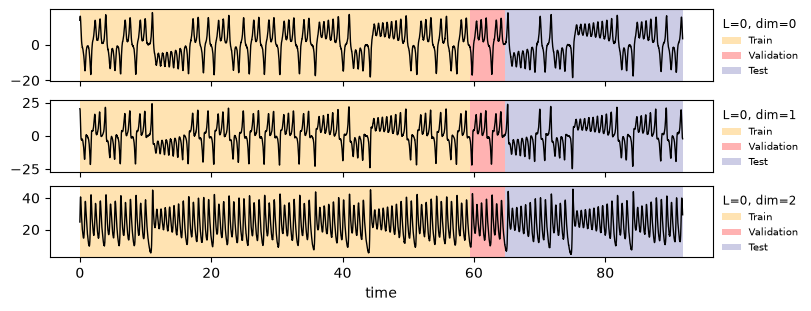


 ----------------- HYPERPARAMETER SEARCH ------------------
 4^2 grid and 4 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 MSE val 


1	 2.000e-01	 1.000e-02	 1.000e-09	 -1.0113


2	 2.000e-01	 2.154e-01	 1.000e-12	 -1.1958


3	 2.000e-01	 4.642e+00	 1.000e-09	 -1.4372


4	 2.000e-01	 1.000e+02	 1.000e-09	 -0.8430


...

18	 2.000e-01	 3.521e+00	 1.000e-12	 -1.7069


19	 2.000e-01	 2.792e+00	 1.000e-12	 -1.4617


20	 2.503e-01	 3.449e+00	 1.000e-12	 -1.4609


seed 0 	 Optimal hyperparameters: [0.2, 0.5466552784793368], 1e-12, MSE: -1.7069024506279005


Running test for L= 0 Overall tests min, max and mean MSE in 1 tests = -1.097, -1.097, -1.097.
Saving new model to /storage0/anovoama/romda/src/config/esn_configs
Configuration saved to ...config/esn_configs/24252dfbe49939a3/esn_config.yaml
Trained matrices saved to ...config/esn_configs/24252dfbe49939a3/trained_matrices.npz
New hash:  24252dfbe49939a3


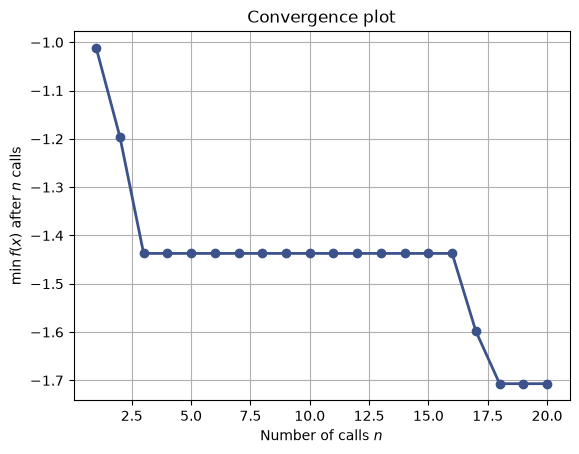

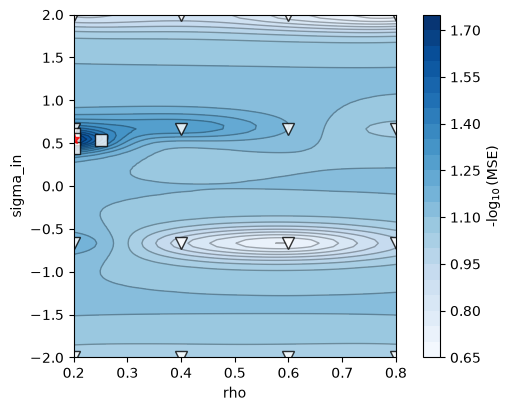

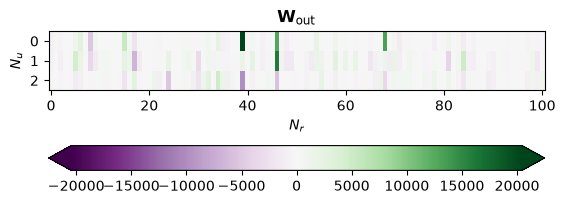

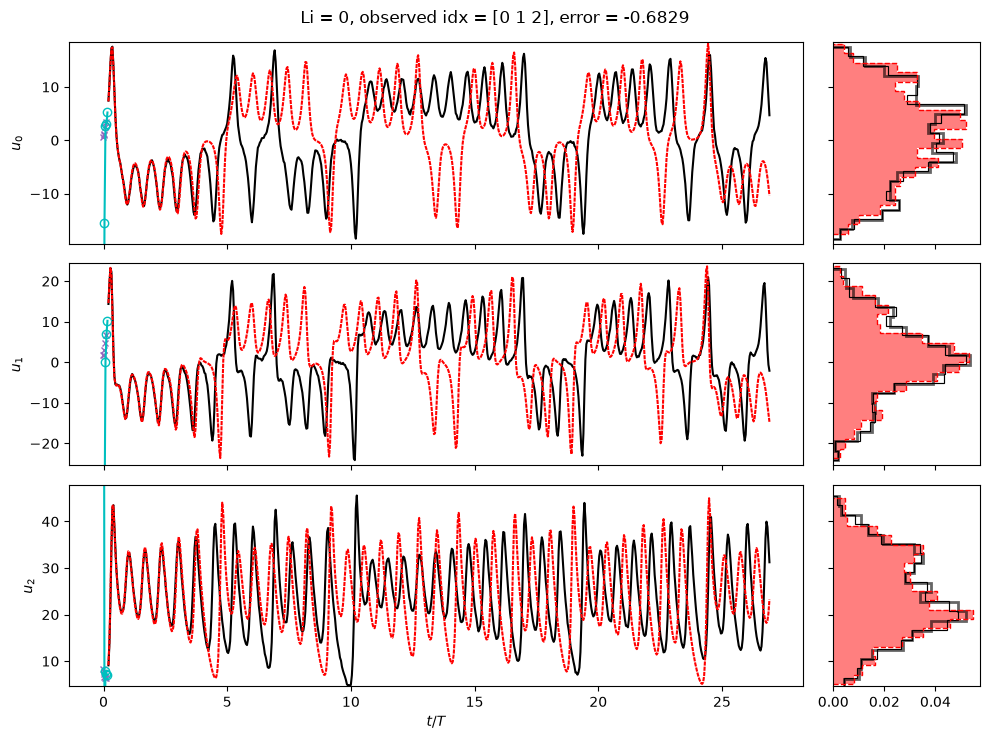

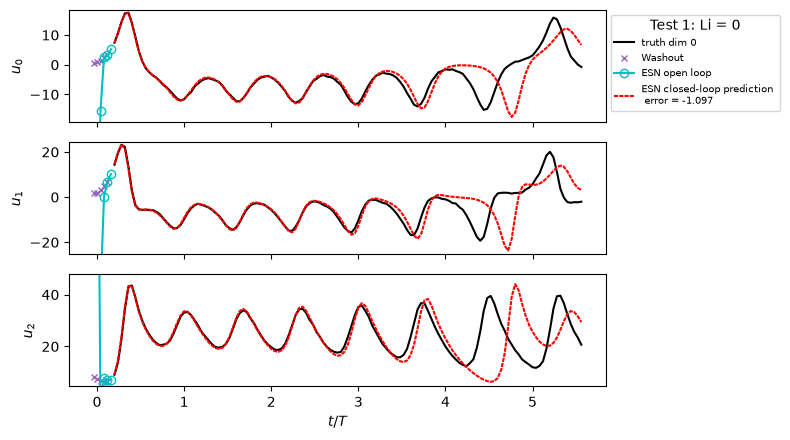

In [8]:
from romda.models.data_driven.esn_config import auto_load_or_create
 

# This should load the same config created avobe
loaded_model_2 = auto_load_or_create(data=training_data, **train_params) 

psi_loaded, t_loaded = loaded_model_2.time_integrate(100)
assert np.allclose(psi_og, psi_loaded), "Loaded model 2 does not produce the same output as the original model"

# Now, we change a hyperparameter to force creating a new model with a different hash. 
train_params_modified = train_params.copy()
train_params_modified['N_units'] = 100

model_new = auto_load_or_create(data=training_data, **train_params_modified, auto_save=True)

print('New hash: ', ESNConfig.from_esn_model(model_new).to_hash())   


# 2. Ensemble of ESNs <a class="anchor" id="fourth"></a>

! Warning: Could not set attribute Na=1 on Ensemble instance.


OK: Initialized my_ESN_ensemble_m10 history with shape: (1, 106, 10) and [0.]


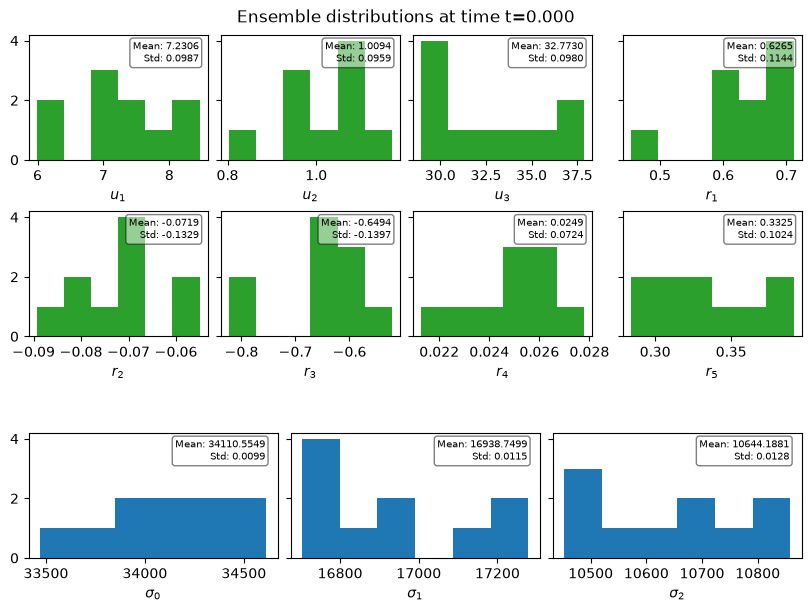

In [9]:

m = 10
ensemble = EnSRKF(parent_model=model_new,
                    m=m, 
                    std_phi=0.1, 
                    est_alpha=['Wout'], # Select the ensemble varying parameters
                    std_alpha=0.02,  # the parameters uncertainty can also be defined individually in a dictionary
                    # alpha_distr='uniform'
                   )

ensemble.visualize_state(max_modes=6)

In [10]:
# from plot_results import plot_obs_timeseries, plot_parameters
for _ in range(10):
    t = ensemble.current_time + 2*t_lyap
    ensemble.forecast_step(t_end=t)  
    


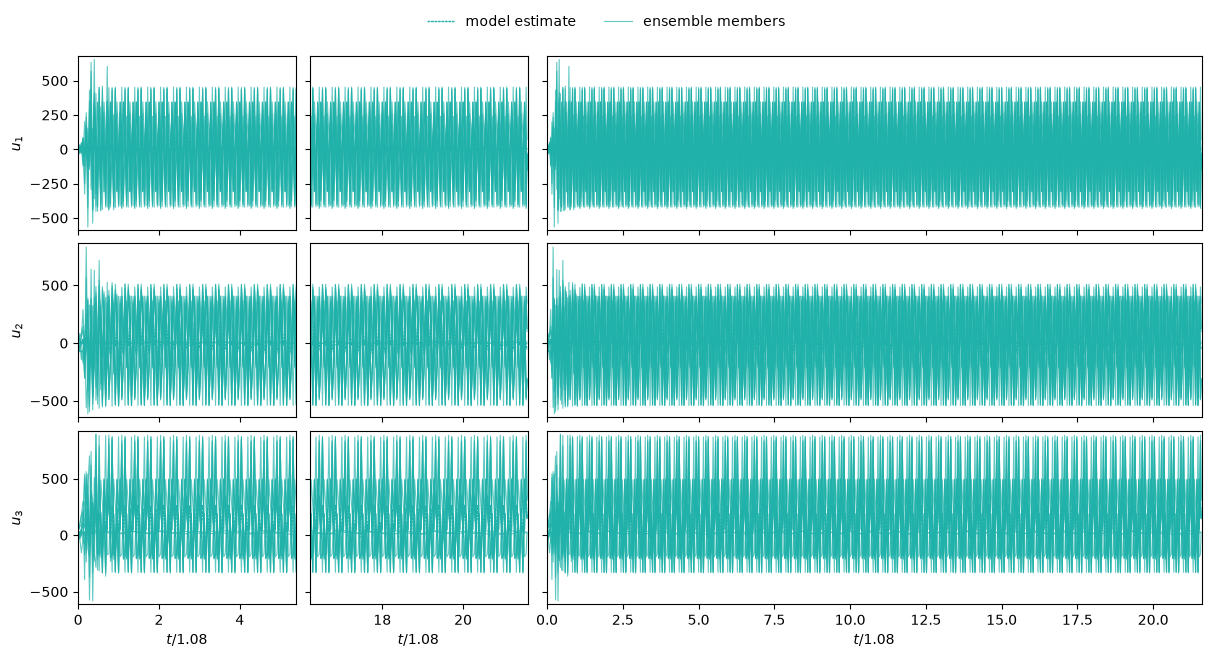

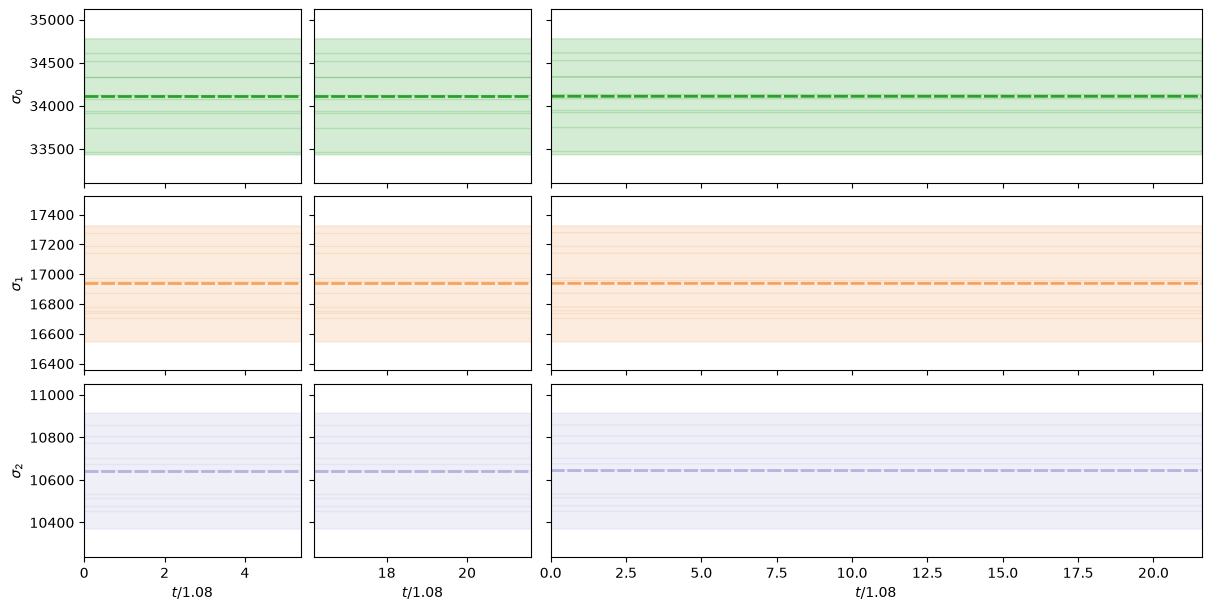

In [11]:
ensemble.visualize_history(plot_members=True, reference_t=t_lyap)

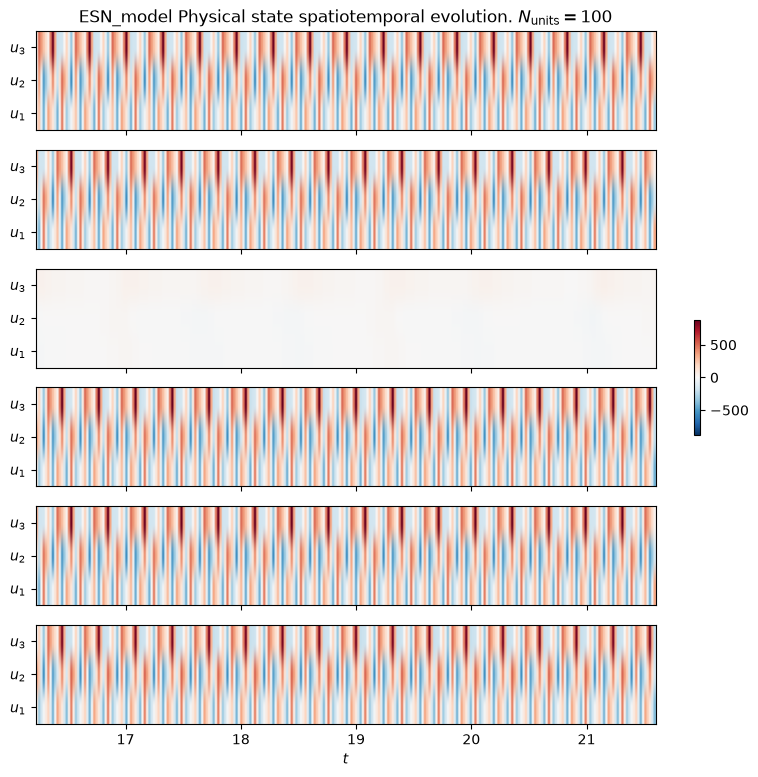

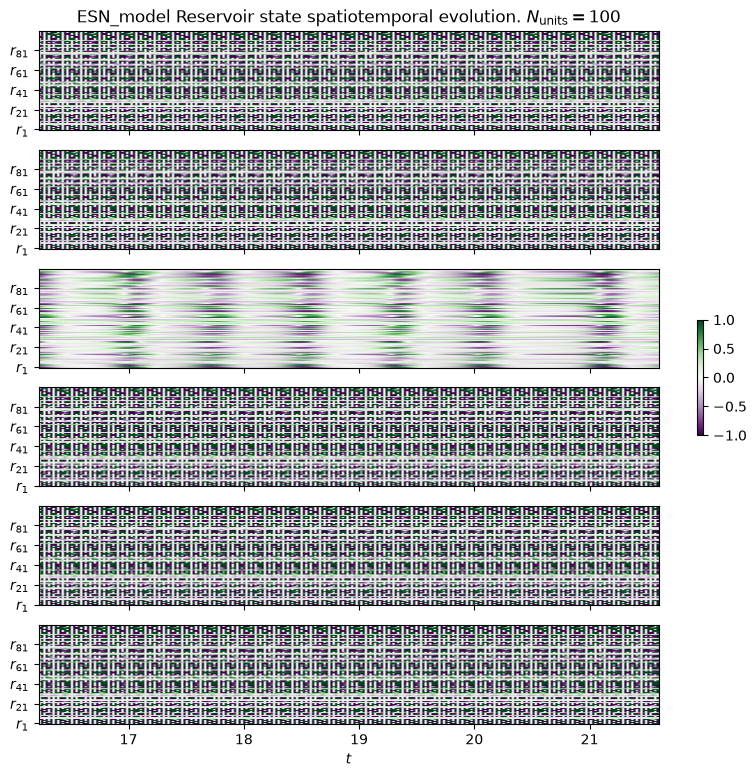

In [12]:
ensemble.model.visualize_spatiotemporal_hist(averaged=False, nrows=6)

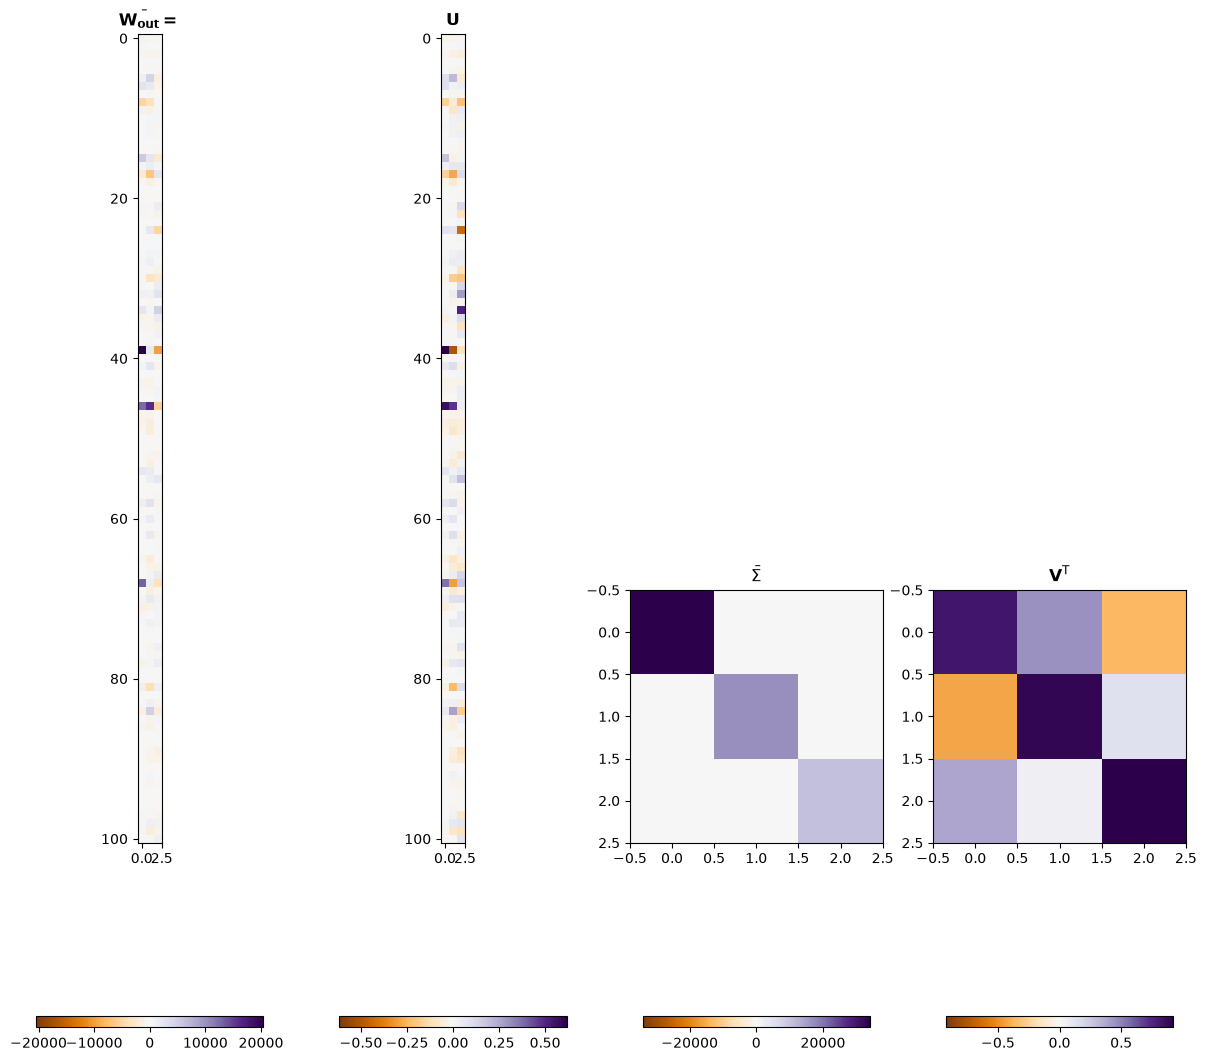

In [13]:
ensemble.model.visualize_config()